# Homework 1 — Seasonal validation of mlp_4out_mean

In [regularization_test.ipynb](../models/regularization_test.ipynb) validation RMSLE depends heavily on the held-out
season: 1.05 (Jul–Sep) to 1.42 (Jan–Mar). Suspect: anomalies. They are dropped from training only, and are far more
common in Jan–May (~6% of rows) than in Nov–Dec (<1%).

So each fold is scored twice:

- **all rows:** as Kaggle scores;
- **clean rows:** without anomaly rows, i.e. the error on real consumption.

The difference is what anomalies cost; the rest is the seasonal effect.

Model: mlp_4out_mean ([mlp.ipynb](../models/mlp.ipynb)). [mean_vs_embedding.ipynb](mean_vs_embedding.ipynb) repeats
this for mlp_4out_emb, with the same result. Folds as in regularization_test.ipynb.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS
from ashrae.data import read_processed, split
from ashrae.features import add_series_mean, build_features
from ashrae.metrics import rmsle
from ashrae.modeling import MeterMLP, make_loaders, predict
from ashrae.tracking import Experiment

EPOCHS = 10
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold
experiment = Experiment("ashrae-season-validation")

2026/09/27 12:43:17 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/.venv/lib/python3.14/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


MLflow: sqlite:///mlflow.db, experiment 'ashrae-season-validation', session 2026-09-27 12:43:17


## Data and features

Features as in mlp.ipynb, plus the series mean computed on each fold's training rows (series without training rows
get their meter type's mean). Validation keeps anomaly rows and remembers which they are.

In [2]:
df = read_processed()


def fold_data(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    X_train = add_series_mean(build_features(train_df, year_median), train_df, train_df)
    X_val = add_series_mean(build_features(val_df, year_median), val_df, train_df)
    train_loader, val_loader, _ = make_loaders(train_df, val_df, X_train, X_val)
    return train_loader, val_loader, val_df.anomaly.to_numpy()


folds = {name: fold_data(months) for name, months in FOLDS.items()}
n_features = folds["Jan–Mar"][0].dataset.x.shape[1]
del df
for name, (_, _, anomaly) in folds.items():
    print(f"{name}: {anomaly.mean():.1%} of validation rows are anomalies")

Jan–Mar: 6.1% of validation rows are anomalies
Apr–Jun: 3.6% of validation rows are anomalies
Jul–Sep: 1.3% of validation rows are anomalies
Oct–Dec: 1.1% of validation rows are anomalies


## Model

mlp_4out_mean: 2 hidden layers of 64 (BatchNorm, ReLU), one output per meter type, Adam, 10 epochs. Code: `MeterMLP`
in [ashrae/modeling.py](../ashrae/modeling.py).

## Training and the two scores

One run per fold. Validation is predicted once and scored on all rows and on clean rows; both go to MLflow.

In [4]:
results = []
for fold, (train_loader, val_loader, anomaly) in folds.items():
    model, run_id = experiment.fit(lambda: MeterMLP(n_features), train_loader, run_name=f"mlp_4out_mean | {fold}",
                                   epochs=EPOCHS, tags={"fold": fold})
    pred, y = predict(model, val_loader), val_loader.dataset.y.numpy()
    scores = {"train": experiment.history(run_id, "train_rmsle")[-1],
              "val_all": rmsle(y, pred), "val_clean": rmsle(y[~anomaly], pred[~anomaly])}
    experiment.log_metrics(run_id, {f"rmsle_{key}": value for key, value in scores.items()})
    results.append({"fold": fold, "anomaly_share": anomaly.mean(), **scores})
    print(f"{fold}: " + ", ".join(f"{k} {v:.3f}" for k, v in scores.items()))

results = pd.DataFrame(results).set_index("fold")

Jan–Mar: train 0.889, val_all 1.459, val_clean 0.979


Apr–Jun: train 0.896, val_all 1.245, val_clean 0.928


Jul–Sep: train 0.896, val_all 1.138, val_clean 1.016


Oct–Dec: train 0.857, val_all 1.122, val_clean 1.035


## Results

,anomaly_share,train,val_all,val_clean,anomaly_cost
fold,,,,,
Jan–Mar,0.061,0.889,1.459,0.979,0.480
Apr–Jun,0.036,0.896,1.245,0.928,0.317
Jul–Sep,0.013,0.896,1.138,1.016,0.122
Oct–Dec,0.011,0.857,1.122,1.035,0.087


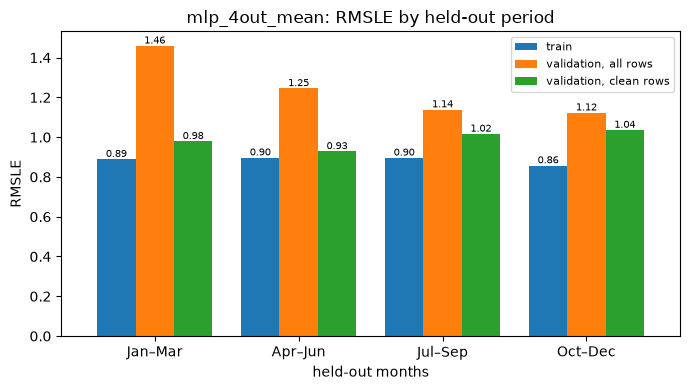

In [5]:
results["anomaly_cost"] = results.val_all - results.val_clean
display(results.round(3))

ax = results[["train", "val_all", "val_clean"]].plot.bar(figsize=(7, 4), rot=0, width=0.8)
ax.set(title="mlp_4out_mean: RMSLE by held-out period", xlabel="held-out months", ylabel="RMSLE")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7)
ax.legend(["train", "validation, all rows", "validation, clean rows"], fontsize=8)
plt.tight_layout()

## Findings

- **Most of the seasonal spread is anomalies.** All rows: 1.12 (Oct–Dec) to 1.46 (Jan–Mar), in the order of the
  anomaly share (1.1% → 6.1%). Clean rows: 0.93–1.04, and Jan–Mar is no longer worst. Anomalies cost 0.48 in Jan–Mar
  and 0.09 in Oct–Dec: a few percent of zeros predicted as normal use dominate the score
  ([EDA §8](../eda/EDA.ipynb#metric)). Anomaly rules: [EDA §9](../eda/EDA.ipynb#broken).
- **The rest is small.** Fold averages: training 0.88, clean 0.99, all rows 1.24. Of the 0.36 gap, ~0.25 is
  anomalies and ~0.1 is season plus memorization. mlp_4out_emb: 0.83 / 0.94 / 1.20, the same split
  ([mean_vs_embedding.ipynb](mean_vs_embedding.ipynb)).
- **So regularization can't close the gap:** it acts only on the small part
  ([regularization_test.ipynb](../models/regularization_test.ipynb)).
- **Per meter, all folds, clean rows** (mlp_4out_emb): hot water is hardest (1.57), electricity easiest (0.42)
  ([mean_vs_embedding.ipynb](mean_vs_embedding.ipynb)).
- **From now on:** compare models on clean rows (real consumption); also report all rows (Kaggle scores every row).

One seed per fold; differences below ~0.01 may be noise.